# 2. Train a model, then roll it out

**You need: one GPU.** Start this notebook inside a GPU allocation:

```bash
srun --account=hclimrep --partition=booster --gres=gpu:1 --ntasks=1 \
     --cpus-per-task=16 --time=01:00:00 --pty bash
export CUDA_VISIBLE_DEVICES=0
```

**Runtime: about 3.5 minutes** (measured: 165 s, 218 s and 266 s on three runs). Most of it is a deliberately
short training run.

What this notebook does:

1. shows you what `make train-tiny` is actually going to run,
2. trains a **200-step** model so you can watch the machinery work (the real
   preset is 4000 steps and takes about half an hour -- do that in a terminal,
   not here),
3. loads the properly trained `tiny` checkpoint that ships with the kit,
4. rolls it out for 10 days against persistence and climatology,
5. rolls it out for 90 days and watches it fall apart.

Step 5 is the point of the notebook. Read
[`docs/03_first_model.md`](../docs/03_first_model.md) alongside.

In [ ]:
import os
import subprocess
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Only the noisy third-party deprecations, NOT everything: a bare
# `filterwarnings("ignore")` also silences all 13 of this kit's own
# diagnostics -- including the figure- and animation-skip warnings, which is
# how a run comes back with 4 figures where the last one had 10 and nobody
# notices.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

print("repo   :", REPO)
print("device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU ONLY")
assert torch.cuda.is_available(), "This notebook needs a GPU. See the cell above."


def run_and_show(cmd, head=0, tail=None, show=True):
    """Run `cmd` and show what it said -- **stderr included**.

    `subprocess.run(..., capture_output=True)` keeps the two streams apart, and a
    cell that prints only `.stdout` throws away the half worth reading. Every
    startup refusal in this kit prints to stdout, but tracebacks, Lightning's
    progress bars and every `warnings.warn` go to **stderr**: printing stdout
    alone turns a failure into `exit 1` and nothing else, and the notebook then
    dies two cells later on a `FileNotFoundError` that looks unrelated -- while
    the message naming the fix sits unread.

    `stderr=STDOUT` merges the two in the order they were written, so the tail of
    a failed run is the reason it failed. A non-zero exit raises here, in the
    cell that caused it, rather than in the next cell that needs the output.
    """
    started = time.time()
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    elapsed = time.time() - started
    lines = [ln for ln in proc.stdout.replace("\r", "\n").splitlines() if ln.strip()]
    keep = 40 if proc.returncode else tail
    shown = lines[-keep:] if keep else lines
    if head and not proc.returncode and len(lines) > head + len(shown):
        shown = lines[:head] + [f"   ... {len(lines) - head - len(shown)} lines ..."] + shown
    if show or proc.returncode:
        print("\n".join(shown))
        print(f"\nexit {proc.returncode}, {elapsed:.0f} s wall")
    if proc.returncode:
        raise RuntimeError(
            f"`{' '.join(cmd[:3])} ...` exited {proc.returncode}. The reason is in the output"
            " above: it is on stderr, which a bare `.stdout` would have discarded."
        )
    return proc

## 1. What is `make train-tiny` going to run?

Everything is launched through geoarches' own entry point with hydra. Ask
`make` to print the recipe instead of running it:

In [ ]:
run_and_show(["make", "-n", "train-tiny"])

Two things in that line matter more than they look:

* **`--config-path` with an absolute path, never `--config-dir`.**
  `--config-dir` is searched *after* geoarches' own `configs/`, both hold a
  `config.yaml`, so geoarches' root config wins -- you silently get its
  `max_steps: 300000`, your `configs/config.yaml` is ignored and nothing warns
  you. That cost a 40-minute GPU run during development.
* **`module=tiny dataloader=glorys_tiny`** are hydra *groups*. Swapping either
  rewires the model, the loss and the metrics together.

You can see the fully composed configuration without running anything:

In [ ]:
recipe = run_and_show(["make", "-n", "train-tiny"], show=False).stdout
argv = recipe.replace("\\\n", " ").split()
composed = run_and_show(argv + ["--cfg", "job", "--resolve"], show=False)
for line in composed.stdout.splitlines():
    if any(k in line for k in ("max_steps", "batch_size", "save_step_frequency",
                               "limit_val_batches", "n_depths", "emb_dim", "component:",
                               "domain", "lr:", "precision")):
        print(line)

## 2. Train something, briefly

We run the **real** command, with `max_steps` cut to 200 so it finishes while
you read. Everything else -- the loss, the metrics, the checkpointing -- is
exactly what a full run does.

The first thing it prints is a **run plan**: the presets in force, the step
budget, which steps will be checkpointed and where, whether this is a fresh start
or a resume, and whether you hold a SLURM allocation. Read it before the loss
scrolls past -- it is the cheapest check that the run is the one you meant.

A bare `++max_steps=200` on a `make` line is parsed by make as a *variable
assignment*, so nothing would ever read it. `make` now refuses that command line
instead of running the preset's full 4000-step budget, and names `HYDRA_ARGS`:
`make train-tiny NAME=my_run HYDRA_ARGS="++max_steps=200 ++save_step_frequency=100"`
is the other way of writing the cell below, which calls the python entry point
directly.

**If the cell below refuses to start, or dies, keep going.** Sections 3 to 6 --
the rollouts, which are the point of this notebook -- load the `tiny` checkpoint
the kit ships (`modelstore/task6_tiny`) and do not depend on this training run at
all. Nothing below reads `notebook_probe`.

In [ ]:
RUN = "notebook_probe"
# Start clean. If modelstore/<name>/checkpoints already exists, geoarches RESUMES
# that run instead of starting a new one -- which is what you want in a terminal
# after a crash, and confusing in a notebook you re-run.
#
# NOT `shutil.rmtree(f"modelstore/{RUN}", ignore_errors=True)`, which is what this
# cell used to be. docs/01 section 1.1 builds `modelstore/` out of symlinks into a
# store shared with the whole room, and `notebook_probe` exists in that store too:
# against a writable share that line deleted a shipped checkpoint out from under
# everybody else in the room -- and `ignore_errors=True` said nothing either way.
# `remove_run_dir` deletes a real directory of your own or refuses, and says which.
from oceanarches import paths  # noqa: E402

print(paths.remove_run_dir(RUN))

cmd = [
    ".venv/bin/python", "-m", "geoarches.main_hydra",
    "--config-path", str(REPO / "configs"),
    "cluster=jupiter_1gpu", "module=tiny", "dataloader=glorys_tiny",
    f"++name={RUN}", "++max_steps=200", "++save_step_frequency=100",
    "++limit_val_batches=4",
]
print(" ".join(cmd), "\n")

proc = run_and_show(cmd, head=22, tail=8)

In [ ]:
run_dir = Path(f"modelstore/{RUN}")
if (run_dir / "checkpoints").is_dir():
    print(sorted(p.name for p in run_dir.iterdir()))
    print(sorted(p.name for p in (run_dir / "checkpoints").iterdir()))
else:
    print(f"{run_dir}/checkpoints does not exist -- the run above did not get that far.")
    print("Read its output, then carry on: section 3 loads the shipped checkpoint instead.")

Two files matter:

* `checkpoints/checkpoint_global_step=200.ckpt` -- the weights;
* **`config.yaml` -- without it the checkpoint cannot be reloaded.** geoarches
  only writes it when `log` is on, which is why this kit ships `log: True` and
  `wandb_mode: offline` in every cluster config. If you ever pass `log=False`,
  you get a model you cannot load again.

Note also that `save_step_frequency` **must divide** `max_steps`: the callback
fires on `global_step % save_step_frequency == 0` and nothing checkpoints at the
end of `fit`, so otherwise the finished model is the one thing that never reaches
disk. That is why the cell above passes `++save_step_frequency=100` alongside
`++max_steps=200`. A run whose arithmetic does not work out is now **refused at
startup**, with the division shown and a value that does divide -- before the GPU
time is spent, rather than after.

## 3. Load a properly trained model

200 steps is not a model. The kit ships one trained for 4500 steps on
`tiny_train`; load that instead.

In [ ]:
from geoarches.lightning_modules.base_module import load_module  # noqa: E402

module, cfg = load_module("modelstore/task6_tiny", device="cuda")
module = module.eval()
from oceanarches.dataloaders.variables import PREPPED_DEPTHS  # noqa: E402

depths = [PREPPED_DEPTHS[i] for i in module.depth_indices]
print(type(module).__name__)
print("component      :", module.component.name)
print("predicts       :", module.component.prognostic)
print("depth levels   :", len(depths), "->", [f"{d:.0f}" for d in depths], "m")
print("parameters     :", sum(p.numel() for p in module.parameters()) / 1e6, "M")
print("lead time      :", module.lead_time_hours, "h")

## 4. A 10-day rollout, against both baselines

We use the shipped evaluation pipeline rather than writing a loop, because the
single most important property of that pipeline is that **the model and the
baselines are scored through exactly the same code, on exactly the same
samples, with one target tensor built once**.

In [ ]:
from hydra.utils import instantiate  # noqa: E402
from torch.utils.data import DataLoader, Subset  # noqa: E402

from oceanarches.evaluation import rollout  # noqa: E402
from oceanarches.evaluation.baselines import (  # noqa: E402
    ClimatologyForecast,
    ModelForecast,
    PersistenceForecast,
)

LEAD = 10
test_args = dict(cfg.dataloader.get("test_args", {}))
test_args["multistep"] = LEAD
dataset = instantiate(cfg.dataloader.dataset, **test_args)
print(f"{len(dataset)} usable initialisations on split '{dataset.domain}'")

inits = rollout.choose_initialisations(len(dataset), n_inits=8, selection="spread")
loader = DataLoader(Subset(dataset, inits), batch_size=4, shuffle=False,
                    collate_fn=rollout.collate_fn)

forecasters = [
    ModelForecast(module, label="tiny"),
    PersistenceForecast(module),
    ClimatologyForecast(module).to("cuda"),
]
metrics = {f.key: rollout.build_metrics(cfg, LEAD, "cuda") for f in forecasters}
losses = {}

started = time.time()
with torch.no_grad():
    for batch in loader:
        rollout.score_batch(module, forecasters,
                            {k: v.to("cuda") for k, v in batch.items()},
                            LEAD, metrics, losses)
print(f"{time.time() - started:.0f} s for {len(inits)} initialisations x {LEAD} days\n")

scores = {key: {n: m.compute() for n, m in group.items()} for key, group in metrics.items()}
for key in losses:
    print(f"loss[{key:12s}] = {losses[key] / len(inits):.4f}")

The loss is normalised so that a **one-day persistence forecast scores about
1**. Over a 10-day rollout it is larger, because later leads are harder. What
matters is the model's number against persistence's, on the same line.

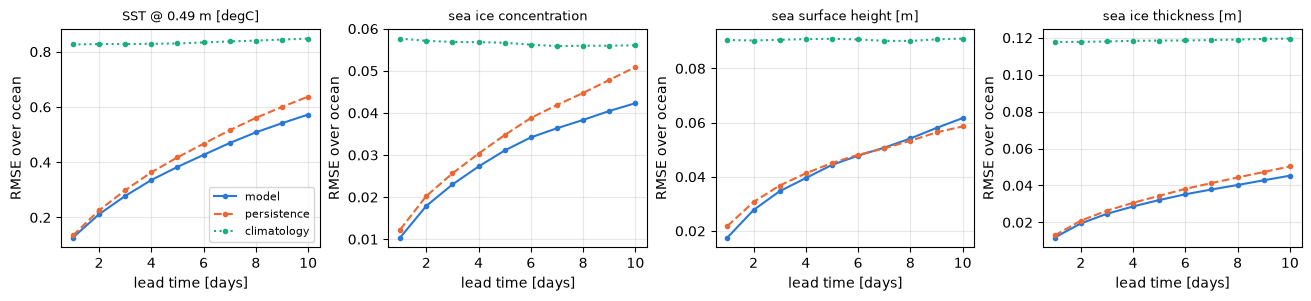

In [ ]:
def curve(key, label):
    """RMSE at each lead time, from the metric labels rmse_<var>_<hours>h."""
    flat = {}
    for group in scores[key].values():
        flat.update({k: float(v) for k, v in group.items()})
    return [flat[f"rmse_{label}_{24 * (i + 1)}h"] for i in range(LEAD)]


panels = [("thetao0m", "SST @ 0.49 m [degC]"), ("siconc", "sea ice concentration"),
          ("zos", "sea surface height [m]"), ("sithick", "sea ice thickness [m]")]
colours = {"model": "#2a78d6", "persistence": "#eb6834", "climatology": "#1baf7a"}
styles = {"model": "-", "persistence": "--", "climatology": ":"}

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9), constrained_layout=True)
days = np.arange(1, LEAD + 1)
for ax, (label, title) in zip(axes, panels):
    for key in ("model", "persistence", "climatology"):
        ax.plot(days, curve(key, label), styles[key], color=colours[key], marker="o",
                ms=3, label=key)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("lead time [days]")
    ax.set_ylabel("RMSE over ocean")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.show()

print(f"{'variable':<12} {'day 1 model':>12} {'day 1 pers.':>12} {'day 10 model':>13} {'day 10 pers.':>13}")
for label, _ in panels:
    m, p = curve("model", label), curve("persistence", label)
    print(f"{label:<12} {m[0]:12.5f} {p[0]:12.5f} {m[-1]:13.5f} {p[-1]:13.5f}")

Read the table, not the curves. **The model is only useful where its number is
below persistence's.** On this model, at day 1 it wins everywhere; by day 10 it
has lost sea surface height.

Climatology is hopeless at day 1 and closing fast by day 10 -- the lead time at
which the model's curve meets the climatology's is where your forecast stops
containing information the calendar did not already have.

## 5. Where is the error, on a map?

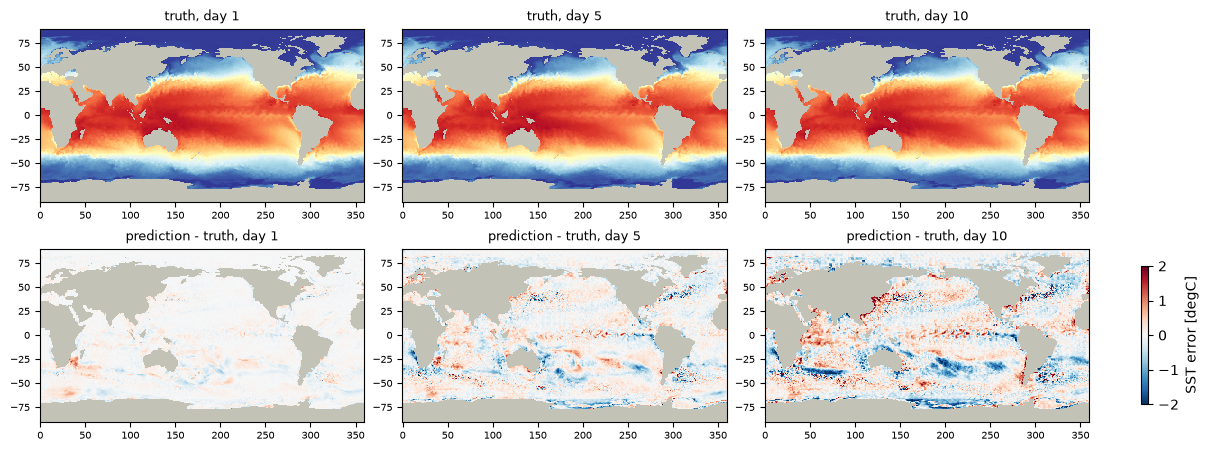

In [ ]:
LAND = "#c3c2b7"
batch = next(iter(DataLoader(Subset(dataset, inits[:1]), batch_size=1,
                             collate_fn=rollout.collate_fn)))
batch = {k: v.to("cuda") for k, v in batch.items()}
with torch.no_grad():
    prediction = module.denormalize_state(module.forward_multistep(batch, iters=LEAD))
    truth = module.denormalize_state(
        rollout.targets_for(module, batch, LEAD)
    )

v = module.component.prognostic_level.index("thetao")
is_ocean = module.mask_level[v, 0].bool().cpu().numpy()


def sst(state, day):
    field = state["level"][0, day - 1, v, 0].float().cpu().numpy()
    return np.where(is_ocean, field, np.nan)


fig, axes = plt.subplots(2, 3, figsize=(12, 4.4), constrained_layout=True)
for col, day in enumerate((1, 5, 10)):
    cmap = plt.get_cmap("RdYlBu_r").copy(); cmap.set_bad(LAND)
    dmap = plt.get_cmap("RdBu_r").copy(); dmap.set_bad(LAND)
    axes[0, col].pcolormesh(np.arange(360), np.arange(-89.5, 90), np.ma.masked_invalid(sst(truth, day)),
                            cmap=cmap, vmin=-2, vmax=32, shading="nearest")
    axes[0, col].set_title(f"truth, day {day}", fontsize=9)
    err = sst(prediction, day) - sst(truth, day)
    im = axes[1, col].pcolormesh(np.arange(360), np.arange(-89.5, 90), np.ma.masked_invalid(err),
                                 cmap=dmap, vmin=-2, vmax=2, shading="nearest")
    axes[1, col].set_title(f"prediction - truth, day {day}", fontsize=9)
for ax in axes.ravel():
    ax.set_facecolor(LAND); ax.tick_params(labelsize=7)
fig.colorbar(im, ax=axes[1, :], shrink=0.8, label="SST error [degC]")
plt.show()

Warm means the model is too warm. Land is grey, never zero -- a Sahara painted
at 0 degC would read as a real measurement.

The error grows where the ocean is most active: the western boundary currents
(Gulf Stream, Kuroshio), the Southern Ocean, and the ice edge.

## 6. Now let it run free for 90 days

Everything above is a 10-day forecast. This is the same model, rolled out for
**90 days**, fed only its own output.

In [ ]:
FREE = 90
free_args = dict(cfg.dataloader.get("test_args", {}))
free_args["multistep"] = FREE
free_dataset = instantiate(cfg.dataloader.dataset, **free_args)
free_batch = next(iter(DataLoader(Subset(free_dataset, [0]), batch_size=1,
                                  collate_fn=rollout.collate_fn)))
free_batch = {k: v.to("cuda") for k, v in free_batch.items()}

started = time.time()
with torch.no_grad():
    free_pred = module.denormalize_state(module.forward_multistep(free_batch, iters=FREE))
    free_truth = module.denormalize_state(rollout.targets_for(module, free_batch, FREE))
print(f"{time.time() - started:.0f} s for {FREE} free-running steps")

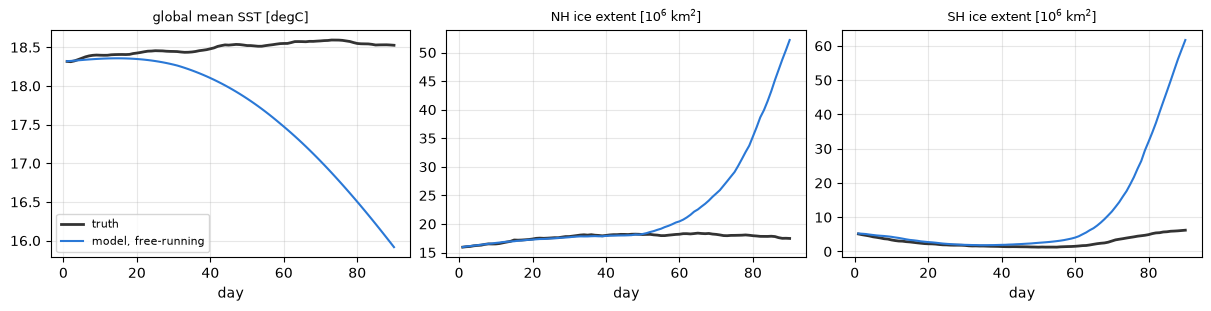

In [ ]:
from oceanarches.metrics.seaice_metrics import cell_areas, hemisphere_masks  # noqa: E402

areas = (cell_areas().to("cuda") * module.mask_surface[0, 0]) / 1e6   # 10^6 km^2
nh, sh = (m.to("cuda") for m in hemisphere_masks())
si = module.component.prognostic_surface.index("siconc")
weights = module.mask_level[v, 0] * torch.cos(
    torch.deg2rad(torch.arange(-89.5, 90, device="cuda"))
).reshape(-1, 1)


def series(state):
    sst_mean, nh_ext, sh_ext = [], [], []
    for day in range(FREE):
        t = state["level"][0, day, v, 0]
        sst_mean.append(float((t * weights).sum() / weights.sum()))
        c = state["surface"][0, day, si, 0]
        nh_ext.append(float((areas * nh * (c > 0.15)).sum()))
        sh_ext.append(float((areas * sh * (c > 0.15)).sum()))
    return np.array(sst_mean), np.array(nh_ext), np.array(sh_ext)


pred_series, truth_series = series(free_pred), series(free_truth)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
titles = ["global mean SST [degC]", "NH ice extent [10$^6$ km$^2$]", "SH ice extent [10$^6$ km$^2$]"]
for ax, title, p, t in zip(axes, titles, pred_series, truth_series):
    ax.plot(np.arange(1, FREE + 1), t, color="#333333", lw=2, label="truth")
    ax.plot(np.arange(1, FREE + 1), p, color="#2a78d6", label="model, free-running")
    ax.set_xlabel("day"); ax.set_title(title, fontsize=9); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.show()

for name, p, t in zip(["global mean SST [degC]", "NH extent", "SH extent"], pred_series, truth_series):
    print(f"{name:24s} day 1: truth {t[0]:8.3f}  model {p[0]:8.3f}    "
          f"day {FREE}: truth {t[-1]:8.3f}  model {p[-1]:8.3f}")

## What just happened

The model does not merely lose skill -- **it leaves the attractor.** The global
ocean cools by a couple of degrees in three months and the Southern Hemisphere
grows more sea ice than the Southern Ocean has room for. The predicted
Antarctic ice edge marches from about -62 degrees latitude to the equator.

**This is not a bug.** It is what autoregressive rollout does to a small model
trained on a single step. The model learned to predict one day ahead *from the
truth*. At step 2 it is fed its own output, which is slightly wrong in a way no
real ocean state ever is; it has never seen such a state, so the next error is
a little larger and a little more structured, and it compounds.

Notice that the 10-day scores in section 4 looked respectable. **Ten days is
not long enough to see this.** A model can score well at the lead time you
tested and be unusable at three times that.

Fixing it is one of the best things you can do in a day:

* train on a multi-step rollout so the model sees its own errors:
  `++module.train.rollout_iterations=2` and up;
* add noise to the training inputs so it learns to be stable off-distribution;
* penalise drift in a global integral (mean SST, total ice area);
* clamp harder.

Measure it with `--free-days 90` before and after, and put the two versions of
this figure side by side.

## Next

* [`notebooks/03_evaluate_and_animate.ipynb`](03_evaluate_and_animate.ipynb) --
  the full scorecard, the figures and the animations.
* [`docs/04_scaling_finetuning.md`](../docs/04_scaling_finetuning.md) -- bigger
  models and fine-tuning.